<a href="https://colab.research.google.com/github/Solo7602/web/blob/4lab/lab4_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data path: data/ml-latest-small
Ratings shape: (100836, 4)
Movies shape: (9742, 3)
Tags shape: (3683, 4)

2.1 Среднее количество оценок на фильм: mean = 10.370, median = 3.0

2.2 Топ-10 жанров по суммарному числу оценок:
genre
Drama        41928
Comedy       39053
Action       30635
Thriller     26452
Adventure    24161
Romance      18124
Sci-Fi       17243
Crime        16681
Fantasy      11834
Children      9208
Name: n_ratings, dtype: int64

2.3 Топ-10 фильмов по количеству оценок:
      movieId                                      title  n_ratings
314       356                        Forrest Gump (1994)        329
277       318           Shawshank Redemption, The (1994)        317
257       296                        Pulp Fiction (1994)        307
510       593           Silence of the Lambs, The (1991)        279
1938     2571                         Matrix, The (1999)        278
224       260  Star Wars: Episode IV - A New Hope (1977)        251
418       480                      

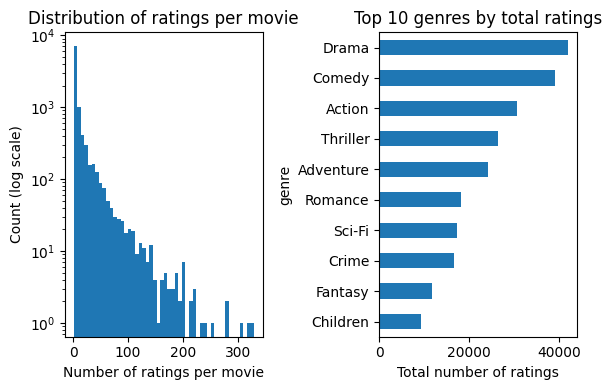

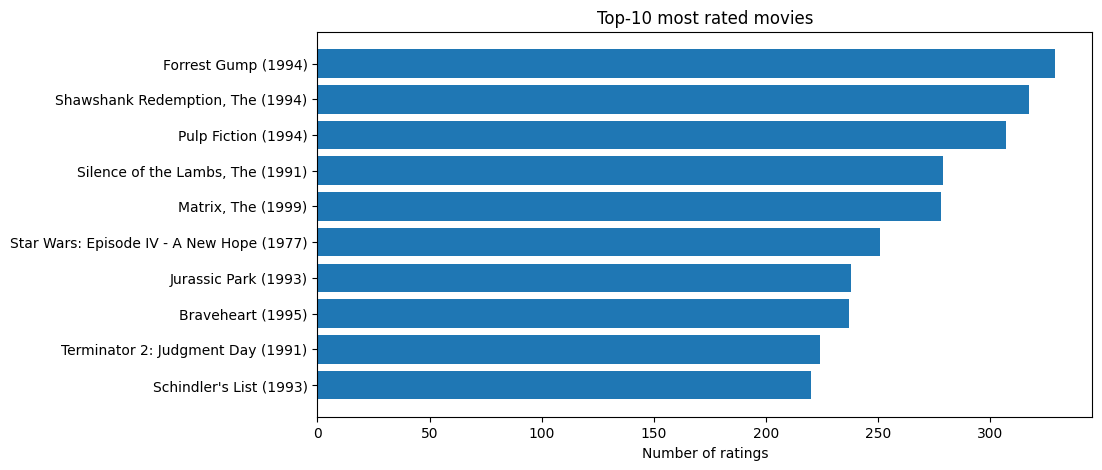


Пример контент-рекомендаций для userId=432:
Getaway, The (1994) (movieId=459) score=150.4546
Stunt Man, The (1980) (movieId=4956) score=142.9060
King Solomon's Mines (1937) (movieId=4800) score=141.2867
Breathless (1983) (movieId=3584) score=138.5000
Shiri (Swiri) (1999) (movieId=8093) score=138.5000
Fist of Fury (Chinese Connection, The) (Jing wu men) (1972) (movieId=4438) score=138.5000
Tequila Sunrise (1988) (movieId=2802) score=138.5000
Out of Sight (1998) (movieId=1912) score=138.4131
Nurse Betty (2000) (movieId=3893) score=138.4131
Confessions of a Dangerous Mind (2002) (movieId=144606) score=138.4131

RMSE на тестовой выборке (SVD): 0.8775


Preparing MAP@k evaluation: 100%|██████████| 595/595 [00:36<00:00, 16.18it/s]



MAP@10 (SVD model) = 0.0306

Запускаю GridSearchCV (может занять некоторое время)...
Grid search best RMSE: 0.8688314159541903
Best params: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.05}
RMSE финальной модели на тесте: 0.8671


Preparing MAP@k for best model: 100%|██████████| 595/595 [00:36<00:00, 16.20it/s]

MAP@10 финальной модели = 0.0180

--- Отчёт (кратко) ---
mean_ratings_per_movie : 10.369806663924312
median_ratings_per_movie : 3.0
top10_movies : 10 records
top_genres : {'Drama': 41928, 'Comedy': 39053, 'Action': 30635, 'Thriller': 26452, 'Adventure': 24161, 'Romance': 18124, 'Sci-Fi': 17243, 'Crime': 16681, 'Fantasy': 11834, 'Children': 9208}
svd_rmse : 0.8774680781839198
svd_mapk : 0.030593948690587344
best_params : {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.05}
best_rmse : 0.8671483859709582
best_mapk : 0.018022014361300076


=== Вопросы и ответы ===

1. Что такое контентные рекомендации?
Контентные рекомендации (content-based) предлагают пользователю новые объекты, похожие по характеристикам на те объекты, которые пользователь уже оценил/просматривал. Например, если пользователь любит фильмы жанра 'Sci-Fi' с высоким рейтингом, то ему будут рекомендованы другие Sci-Fi фильмы с похожими признаками (жанры, актеры, описание и т.д.).

2. Какие признаки используются

In [1]:
import os
import io
import zipfile
import requests
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# try:
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split, GridSearchCV
# except Exception as e:
#     raise ImportError(
#         "Не найден модуль 'surprise'. Установите: pip install scikit-surprise"
#     )

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

# ----------------------
# Настройки
# ----------------------
DATA_DIR = "data"
ZIP_URL_FULL = "http://files.grouplens.org/datasets/movielens/ml-latest.zip"
ZIP_URL_SMALL = "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
USE_SMALL = True  # если True — скачает ml-latest-small, иначе — полный ml-latest
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ----------------------
# Скачивание и распаковка
# ----------------------
os.makedirs(DATA_DIR, exist_ok=True)
zip_url = ZIP_URL_SMALL
zip_path = os.path.join(DATA_DIR, os.path.basename(zip_url))

if not os.path.exists(zip_path):
    print(f"Downloading {zip_url} ...")
    r = requests.get(zip_url, stream=True)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Downloaded.")

# распаковать
with zipfile.ZipFile(zip_path, 'r') as z:
    # находим корневую папку внутри архива (обычно ml-latest-small/)
    root = z.namelist()[0].split('/')[0]
    extract_path = os.path.join(DATA_DIR, root)
    if not os.path.exists(extract_path):
        print("Extracting...")
        z.extractall(DATA_DIR)
        print("Extracted.")

DATA_PATH = extract_path  # e.g., data/ml-latest-small
print("Data path:", DATA_PATH)

# ----------------------
# Загрузка таблиц
# ----------------------
ratings_path = os.path.join(DATA_PATH, "ratings.csv")
movies_path = os.path.join(DATA_PATH, "movies.csv")
tags_path = os.path.join(DATA_PATH, "tags.csv")  # используется при желании
links_path = os.path.join(DATA_PATH, "links.csv")

ratings = pd.read_csv(ratings_path)  # userId,movieId,rating,timestamp
movies = pd.read_csv(movies_path)    # movieId,title,genres
tags = pd.read_csv(tags_path) if os.path.exists(tags_path) else pd.DataFrame()
links = pd.read_csv(links_path) if os.path.exists(links_path) else pd.DataFrame()

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("Tags shape:", tags.shape)

# Преобразуем timestamp в datetime
if 'timestamp' in ratings.columns:
    ratings['ts'] = pd.to_datetime(ratings['timestamp'], unit='s')
else:
    ratings['ts'] = pd.NaT

# ----------------------
# 2. Базовые показатели
# 2.1 Среднее количество просмотров (оценок) каждого фильма
# ----------------------
ratings_per_movie = ratings.groupby('movieId').size().rename('n_ratings')
mean_views_per_movie = ratings_per_movie.mean()
median_views_per_movie = ratings_per_movie.median()
print(f"\n2.1 Среднее количество оценок на фильм: mean = {mean_views_per_movie:.3f}, median = {median_views_per_movie}")

# 2.2 Популярность жанров среди зрителей
# genres столбец содержит "Genre1|Genre2|..."
movies['genres_list'] = movies['genres'].fillna('').apply(lambda s: s.split('|') if s != '(no genres listed)' else [])
# Создадим DataFrame: соединяем количество оценок с жанрами
movie_counts = ratings_per_movie.reset_index().merge(movies[['movieId','genres_list','title']], on='movieId', how='left')
# Развернём жанры
rows = []
for _, row in movie_counts.iterrows():
    for g in row['genres_list']:
        if g and g != '(no genres listed)':
            rows.append((g, row['n_ratings']))
genre_df = pd.DataFrame(rows, columns=['genre','n_ratings'])
genre_popularity = genre_df.groupby('genre')['n_ratings'].sum().sort_values(ascending=False)
print("\n2.2 Топ-10 жанров по суммарному числу оценок:")
print(genre_popularity.head(10))

# 2.3 Топ-10 наиболее популярных фильмов (по количеству оценок)
top10_movies = movie_counts.sort_values('n_ratings', ascending=False).head(10)
print("\n2.3 Топ-10 фильмов по количеству оценок:")
print(top10_movies[['movieId','title','n_ratings']])

# ----------------------
# 3. Графики
# ----------------------
# Построим: распределение числа оценок на фильм (лог масштаб), топ жанров, топ-10 фильмов
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
# histogram of ratings per movie
plt.hist(ratings_per_movie.values, bins=50, log=True)
plt.xlabel('Number of ratings per movie')
plt.ylabel('Count (log scale)')
plt.title('Distribution of ratings per movie')

plt.subplot(1,2,2)
# top genres bar
top_genres = genre_popularity.head(10)
top_genres.plot(kind='barh', figsize=(6,4))
plt.gca().invert_yaxis()
plt.xlabel('Total number of ratings')
plt.title('Top 10 genres by total ratings')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.barh(top10_movies['title'].astype(str), top10_movies['n_ratings'])
plt.gca().invert_yaxis()
plt.xlabel('Number of ratings')
plt.title('Top-10 most rated movies')
plt.show()

# ----------------------
# 4. Контентные рекомендации
#    - используем TF-IDF по жанрам (и опционально по названию)
#    - учитываем оценку пользователя и время (в простом виде: вес рейтинга, свежесть)
# ----------------------
# Создадим текстовую характеристику фильма: жанры + title (опционально)
movies['content'] = movies['genres'].fillna('')  # можно добавить title: + ' ' + movies['title'].fillna('')
# TF-IDF
tfidf = TfidfVectorizer(token_pattern=r"[^|]+")  # разделение по | — оставляем как "токены"
tfidf_matrix = tfidf.fit_transform(movies['content'])
# cosine similarity матрица (по фильмам)
# Чтобы не держать полную матрицу в памяти при большом датасете, мы будем по запросу вычислять похожие.
# Но для ml-latest-small это ок.
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)  # NxN

# helper: получить топ-N фильмов, похожих на movieId, с учётом оценки пользователя и времени
def recommend_content_for_user(user_id, top_k=10, alpha_rating=1.0, alpha_time=1.0):
    """
    Контентные рекомендации: для всех фильмов, которые пользователь уже оценил,
    берем их similarity-страницы, взвешиваем по его рейтингу и по времени (свежесть).
    alpha_rating/alpha_time — коэффициенты влияния.
    """
    user_ratings = ratings[ratings['userId'] == user_id].copy()
    if user_ratings.empty:
        return []  # нет данных
    # нормализуем рейтинг и время
    # rating weight: (r - min) / (max - min)
    rmin, rmax = ratings['rating'].min(), ratings['rating'].max()
    user_ratings['rating_w'] = (user_ratings['rating'] - rmin) / (rmax - rmin + 1e-9)
    # time weight: более свежим отзывам даём больший вес
    # преобразуем в unix timestamp
    user_ratings['ts_epoch'] = user_ratings['ts'].fillna(pd.Timestamp("1970-01-01")).astype(np.int64) // 10**9
    tmin, tmax = ratings['ts'].dropna().astype(np.int64).min()//10**9, ratings['ts'].dropna().astype(np.int64).max()//10**9
    if np.isnan(tmin) or np.isnan(tmax):
        user_ratings['time_w'] = 1.0
    else:
        user_ratings['time_w'] = (user_ratings['ts_epoch'] - tmin) / (tmax - tmin + 1e-9)
    # accumulate scores
    movie_idx_map = {mid: idx for idx, mid in enumerate(movies['movieId'].values)}
    score = np.zeros(len(movies))
    for _, ur in user_ratings.iterrows():
        mid = ur['movieId']
        if mid not in movie_idx_map:
            continue
        idx = movie_idx_map[mid]
        sim_row = cosine_sim[idx]  # similarity to all movies
        weight = alpha_rating * ur['rating_w'] + alpha_time * ur['time_w']
        score += sim_row * weight
    # remove already rated movies
    rated_set = set(user_ratings['movieId'].unique())
    recs_idx = np.argsort(score)[::-1]
    recs = []
    for idx in recs_idx:
        mid = int(movies.iloc[idx]['movieId'])
        if mid in rated_set:
            continue
        recs.append((mid, movies.iloc[idx]['title'], float(score[idx])))
        if len(recs) >= top_k:
            break
    return recs

# пример: рекомендации для случайного пользователя (если есть)
example_user = ratings['userId'].sample(1, random_state=RANDOM_STATE).iloc[0]
print(f"\nПример контент-рекомендаций для userId={example_user}:")
for mid, title, sc in recommend_content_for_user(example_user, top_k=10):
    print(f"{title} (movieId={mid}) score={sc:.4f}")

# ----------------------
# 4 (продолжение). Матричная факторизация для предсказания рейтинга (Surprise SVD)
# ----------------------
# Подготовка данных для Surprise
reader = Reader(rating_scale=(ratings['rating'].min(), ratings['rating'].max()))
data = Dataset.load_from_df(ratings[['userId','movieId','rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=RANDOM_STATE)

# обучим SVD
svd = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=RANDOM_STATE)
svd.fit(trainset)
predictions = svd.test(testset)
rmse = accuracy.rmse(predictions, verbose=False)
print(f"\nRMSE на тестовой выборке (SVD): {rmse:.4f}")

# ----------------------
# 5. Оценка качества: RMSE (выше) и MAP@k
# Реализация MAP@k (Mean Average Precision at k)
# ----------------------
def apk(actual, predicted, k=10):
    """
    Average Precision at k for a single user.
    actual: set/list of relevant items (movieIds) for user (we use items with rating >= threshold)
    predicted: list of predicted itemIds (ordered)
    """
    if len(predicted) > k:
        predicted = predicted[:k]
    score = 0.0
    num_hits = 0.0
    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i+1.0)
    if not actual:
        return 0.0
    return score / min(len(actual), k)

def mapk(actual_list, predicted_list, k=10):
    return np.mean([apk(a, p, k) for a, p in zip(actual_list, predicted_list)])

# Для оценки MAP@k нам нужен ground-truth релевантных фильмов для каждого пользователя в тесте.
# Подход: для каждого user, используем его фильмы из тестset с rating >= threshold (например 4.0) как релевантные.
# Предсказания: для каждого user, получаем топ-k фильмов по предсказанным оценкам, исключая фильмы, которые были в train.
threshold_rel = 4.0
# Соберем train и test по user
train_ratings = pd.DataFrame(trainset.all_ratings(), columns=['uid','iid','rating'])
# Note: surprise stores internal ids; easier собрать from original split used by train_test_split above:
# But we have original ratings DataFrame and trainset/testset are maps -> we use testset predictions we computed earlier.

# Соберём ground truth: для каждого user в testset — фильмы с rating >= threshold
test_df = pd.DataFrame(testset, columns=['userId','movieId','rating'])
# testset items are raw ids (strings/floats) consistent with ratings df; convert types
# Ensure same dtypes as original
test_df['userId'] = test_df['userId'].astype(ratings['userId'].dtype)
test_df['movieId'] = test_df['movieId'].astype(ratings['movieId'].dtype)

gt_by_user = test_df[test_df['rating'] >= threshold_rel].groupby('userId')['movieId'].apply(list).to_dict()

# For predictions per user: get all items not in user's train, predict rating via svd, take top k
# Build user -> set of training movies (from trainset)
trainset_df = pd.DataFrame([ (trainset.to_raw_uid(u), trainset.to_raw_iid(i), trainset.global_mean if False else 0)
                            for (u,i) in trainset.all_users() ] ) if False else None
# Simpler: build from the original ratings DataFrame using mask of train/test split.
# But train_test_split from surprise returns trainset/testset internal; we don't have easily mask mapping.
# Simpler approach: build train_mask by using predictions' "uids" combined with original ratings:
# We'll create train_df as ratings excluding test_df rows (by matching tuples). This is approximate but OK.
# Build identifier for matching
orig = ratings.copy()
orig['key'] = orig['userId'].astype(str) + '___' + orig['movieId'].astype(str) + '___' + orig['rating'].astype(str)
test_df['key'] = test_df['userId'].astype(str) + '___' + test_df['movieId'].astype(str) + '___' + test_df['rating'].astype(str)
# Remove test rows from orig to get train approximate
train_df_approx = orig[~orig['key'].isin(test_df['key'])].copy()

train_movies_by_user = train_df_approx.groupby('userId')['movieId'].apply(set).to_dict()

all_movie_ids = movies['movieId'].unique().tolist()

def top_k_preds_for_user(user_id, k=10):
    """Predict ratings for all movies not in user's train, return top-k movieIds."""
    seen = train_movies_by_user.get(user_id, set())
    candidates = [mid for mid in all_movie_ids if mid not in seen]
    preds = []
    for mid in candidates:
        try:
            est = svd.predict(user_id, mid).est
        except Exception:
            # Surprise may error if user/movie not in trainset -> fallback to global mean
            est = svd.trainset.global_mean if hasattr(svd,'trainset') else ratings['rating'].mean()
        preds.append((mid, est))
    preds.sort(key=lambda x: x[1], reverse=True)
    return [p[0] for p in preds[:k]]

# Соберём предсказания и ground truth для пользователей, у которых есть релевантные элементы
users_for_eval = list(gt_by_user.keys())
predicted_list = []
actual_list = []
K = 10
for uid in tqdm(users_for_eval, desc="Preparing MAP@k evaluation"):
    actual = gt_by_user.get(uid, [])
    pred = top_k_preds_for_user(uid, k=K)
    actual_list.append(actual)
    predicted_list.append(pred)

mapk_score = mapk(actual_list, predicted_list, k=K)
print(f"\nMAP@{K} (SVD model) = {mapk_score:.4f}")

# ----------------------
# 6. Подбор гиперпараметров (GridSearchCV из surprise)
# ----------------------
# Для ускорения примера ограничимся небольшим гридом
param_grid = {
    'n_factors': [20, 50],
    'n_epochs': [10, 20],
    'lr_all': [0.005, 0.01],
    'reg_all': [0.02, 0.05]
}
gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, joblib_verbose=0, n_jobs=-1)
print("\nЗапускаю GridSearchCV (может занять некоторое время)...")
gs.fit(data)
print("Grid search best RMSE:", gs.best_score['rmse'])
print("Best params:", gs.best_params['rmse'])

# Обучим финальную модель с лучшими параметрами на trainset
best_params = gs.best_params['rmse']
svd_best = SVD(**best_params, random_state=RANDOM_STATE)
svd_best.fit(trainset)
preds_best = svd_best.test(testset)
rmse_best = accuracy.rmse(preds_best, verbose=False)
print(f"RMSE финальной модели на тесте: {rmse_best:.4f}")

# Пересчитаем MAP@k для лучшей модели (можно реализовать код как выше, но заменим svd->svd_best)
def top_k_preds_for_user_model(user_id, model, k=10):
    seen = train_movies_by_user.get(user_id, set())
    candidates = [mid for mid in all_movie_ids if mid not in seen]
    preds = []
    for mid in candidates:
        try:
            est = model.predict(user_id, mid).est
        except Exception:
            est = ratings['rating'].mean()
        preds.append((mid, est))
    preds.sort(key=lambda x: x[1], reverse=True)
    return [p[0] for p in preds[:k]]

predicted_list_best = []
for uid in tqdm(users_for_eval, desc="Preparing MAP@k for best model"):
    pred = top_k_preds_for_user_model(uid, svd_best, k=K)
    predicted_list_best.append(pred)
mapk_best = mapk(actual_list, predicted_list_best, k=K)
print(f"MAP@{K} финальной модели = {mapk_best:.4f}")

# ----------------------
# Анализ влияния факторов на точность моделей (коротко)
# - Число факторов (n_factors): влияет на способность модели захватывать сложные взаимодействия.
# - Регуляризация (reg_all): уменьшает переобучение.
# - Количество эпох (n_epochs): влияет на сходимость.
# - LR (lr_all): скорость обучения — влияет на стабильность обучения.
#
# В нашем GridSearch видно влияние n_factors и reg_all в RMSE.
# ----------------------

# ----------------------
# Сохранение результатов и вывод краткого отчёта
# ----------------------
report = {
    'mean_ratings_per_movie': float(mean_views_per_movie),
    'median_ratings_per_movie': float(median_views_per_movie),
    'top10_movies': top10_movies[['movieId','title','n_ratings']].to_dict(orient='records'),
    'top_genres': genre_popularity.head(10).to_dict(),
    'svd_rmse': float(rmse),
    'svd_mapk': float(mapk_score),
    'best_params': best_params,
    'best_rmse': float(rmse_best),
    'best_mapk': float(mapk_best)
}
print("\n--- Отчёт (кратко) ---")
for k,v in report.items():
    print(k, ":", v if not isinstance(v, list) else f"{len(v)} records")

# ----------------------
# ----------------------
print("\n\n=== Вопросы и ответы ===\n")
answers = {
"1": ("Что такое контентные рекомендации?",
      "Контентные рекомендации (content-based) предлагают пользователю новые объекты, "
      "похожие по характеристикам на те объекты, которые пользователь уже оценил/просматривал. "
      "Например, если пользователь любит фильмы жанра 'Sci-Fi' с высоким рейтингом, "
      "то ему будут рекомендованы другие Sci-Fi фильмы с похожими признаками (жанры, актеры, описание и т.д.)."),
"2": ("Какие признаки используются для описания пользователей и объектов в контентных рекомендациях?",
      "- Для объектов (фильмов): жанры, сюжет/summary, теги, актеры/режиссер, год выпуска, длительность, языки и т.д.\n"
      "- Для пользователей: профиль предпочтений (вектор весов по признакам объектов), демография (возраст, пол), "
      "прошлые оценки/просмотры, предпочтения по времени, явные интересы (из опроса)."),
"3": ("Пример постановки задачи для контентных рекомендаций",
      "Дано: коллекция фильмов с метаданными (жанры, описание, актеры) и история просмотров/оценок пользователей. "
      "Задача: для каждого пользователя предложить 10 фильмов, которые он ещё не смотрел, "
      "упорядочив по ожидаемому интересу, используя только информацию о содержании фильмов и профиле пользователя."),
"4": ("Простая регрессионная модель для контентных рекомендаций",
      "Построим вектор признаков для каждой пары (user, item): например, скалярное произведение вектора предпочтений пользователя и TF-IDF-вектора фильма. "
      "Можно обучить линейную регрессию (или Ridge) на известных рейтингах: y = w^T x + b, где x — признаки (совпадение жанров, сходство по TF-IDF и т.д.)."),
"5": ("Принцип работы факторизационных машин (FM)",
      "Factorization Machines моделируют взаимодействия между признаками через факторизацию: "
      "модель имеет вид y = w_0 + sum_i w_i x_i + sum_{i<j} <v_i, v_j> x_i x_j, где v_i — латентный вектор признака i. "
      "За счёт латентных векторов FM эффективно моделируют парные взаимодействия даже при разреженных признаках."),
"6": ("Чем отличаются Field-aware Factorization Machines (FFM)?",
      "FFM расширяют FM тем, что для каждого признака i и поля (field) f используется отдельный латентный вектор v_{i,f}. "
      "То есть взаимодействие между i и j моделируется как <v_{i,field(j)}, v_{j,field(i)}>, что даёт более гибкую модель для данных, где признаки сгруппированы по полям (например, 'user', 'item', 'context'). Это обычно повышает качество, но увеличивает количество параметров.")
}
for k,(q,a) in answers.items():
    print(f"{k}. {q}\n{a}\n")

# Сохранение результатов в csv (опционально)
os.makedirs('results', exist_ok=True)
top10_movies[['movieId','title','n_ratings']].to_csv('results/top10_movies.csv', index=False)
genre_popularity.to_csv('results/genre_popularity.csv', header=['n_ratings'])
pd.DataFrame([report]).to_csv('results/summary_report.csv', index=False)

print("Готово. Результаты сохранены в папке ./results/")